# Principal Component Analysis with Cancer Data

In [167]:
#Import all the necessary modules
#Import all the necessary modules
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.decomposition import PCA
from scipy.stats import zscore

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [168]:
# Read the dataset

cancer_df = pd.read_csv("cancer.csv")  
cancer_df.head(10)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


   Id columns is to identify rows hence can be skipped in analysis   
   All columns have numerical values   
   Class would be the target variable. Should be removed when PCA is done   

# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [169]:
print("DataType of Each Columns are : " , cancer_df.dtypes)
print("Shape of Dataset is :" , cancer_df.shape)

DataType of Each Columns are :  ID                              int64
ClumpThickness                  int64
Cell Size                       int64
Cell Shape                      int64
Marginal Adhesion               int64
Single Epithelial Cell Size     int64
Bare Nuclei                    object
Normal Nucleoli                 int64
Bland Chromatin                 int64
Mitoses                         int64
Class                           int64
dtype: object
Shape of Dataset is : (699, 11)


# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


We could see "?" values in "Bare Nuclei" column, this should be removed from data set
Check for missing value in any other column

In [173]:
# Bare Nuclei is an object type though it is supposed to be numeric. Check if all the rows in this column are digits 

#temp = pd.DataFrame(cancer_df.Bare Nuclei.str.isdigit())  # if the string is made of digits store True else False  in the hp column 
#temp[temp["Bare Nuclei"] == False]   # from temp take only those rows where hp has false

# On inspecting records number 32, 126 etc, we find "?" in the columns. Replace them with "nan"
#Replace them with nan and remove the records from the data frame that have "nan"
cancer_df = cancer_df.replace('?', np.nan)
cancer_df = cancer_df.apply(lambda x: x.fillna(x.median()),axis=0)


# converting the hp column from object / string type to float
cancer_df["Bare Nuclei"] = cancer_df["Bare Nuclei"].astype('float64')  


In [175]:
cancer_df["Bare Nuclei"].unique()

array([ 1., 10.,  2.,  4.,  3.,  9.,  7.,  5.,  8.,  6.])

16 values are corrupted. We can either delete them as it forms roughly 2% of data. Here we would like to impute it with suitable values

In [176]:
cancer_df.apply(lambda x: x.fillna(x.median()),axis=0)
cancer_df.head(3)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2


In [177]:
a=cancer_df["Bare Nuclei"]

In [146]:
cancer_df.shape

(683, 11)

In [147]:
cancer_df.drop(['ID'], axis=1,inplace=True)
cancer_df.head(3)

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2


16 values are corrupted. We can either delete them as it forms roughly 2% of data.
Here we would like to impute it with suitable values

# Q4. Perform bi variate analysis including correlation & pairplots. 


In [150]:
# Check for correlation of variable
cancer_df.corr()

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Normal Nucleoli,Bland Chromatin,Mitoses,Class
ClumpThickness,1.000000,0.642481,0.653470,0.487829,0.523596,0.553742,0.534066,0.350957,0.714790
Cell Size,0.642481,1.000000,0.907228,0.706977,0.753544,0.755559,0.719346,0.460755,0.820801
Cell Shape,0.653470,0.907228,1.000000,0.685948,0.722462,0.735344,0.717963,0.441258,0.821891
Marginal Adhesion,0.487829,0.706977,0.685948,1.000000,0.594548,0.668567,0.603121,0.418898,0.706294
Single Epithelial Cell Size,0.523596,0.753544,0.722462,0.594548,1.000000,0.618128,0.628926,0.480583,0.690958
Normal Nucleoli,0.553742,0.755559,0.735344,0.668567,0.618128,1.000000,0.665602,0.346011,0.758228
Bland Chromatin,0.534066,0.719346,0.717963,0.603121,0.628926,0.665602,1.000000,0.433757,0.718677
Mitoses,0.350957,0.460755,0.441258,0.418898,0.480583,0.346011,0.433757,1.000000,0.423448
Class,0.714790,0.820801,0.821891,0.706294,0.690958,0.758228,0.718677,0.423448,1.000000


Clearly few columns have correlation as high as 0.9

C:\Users\Admin\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


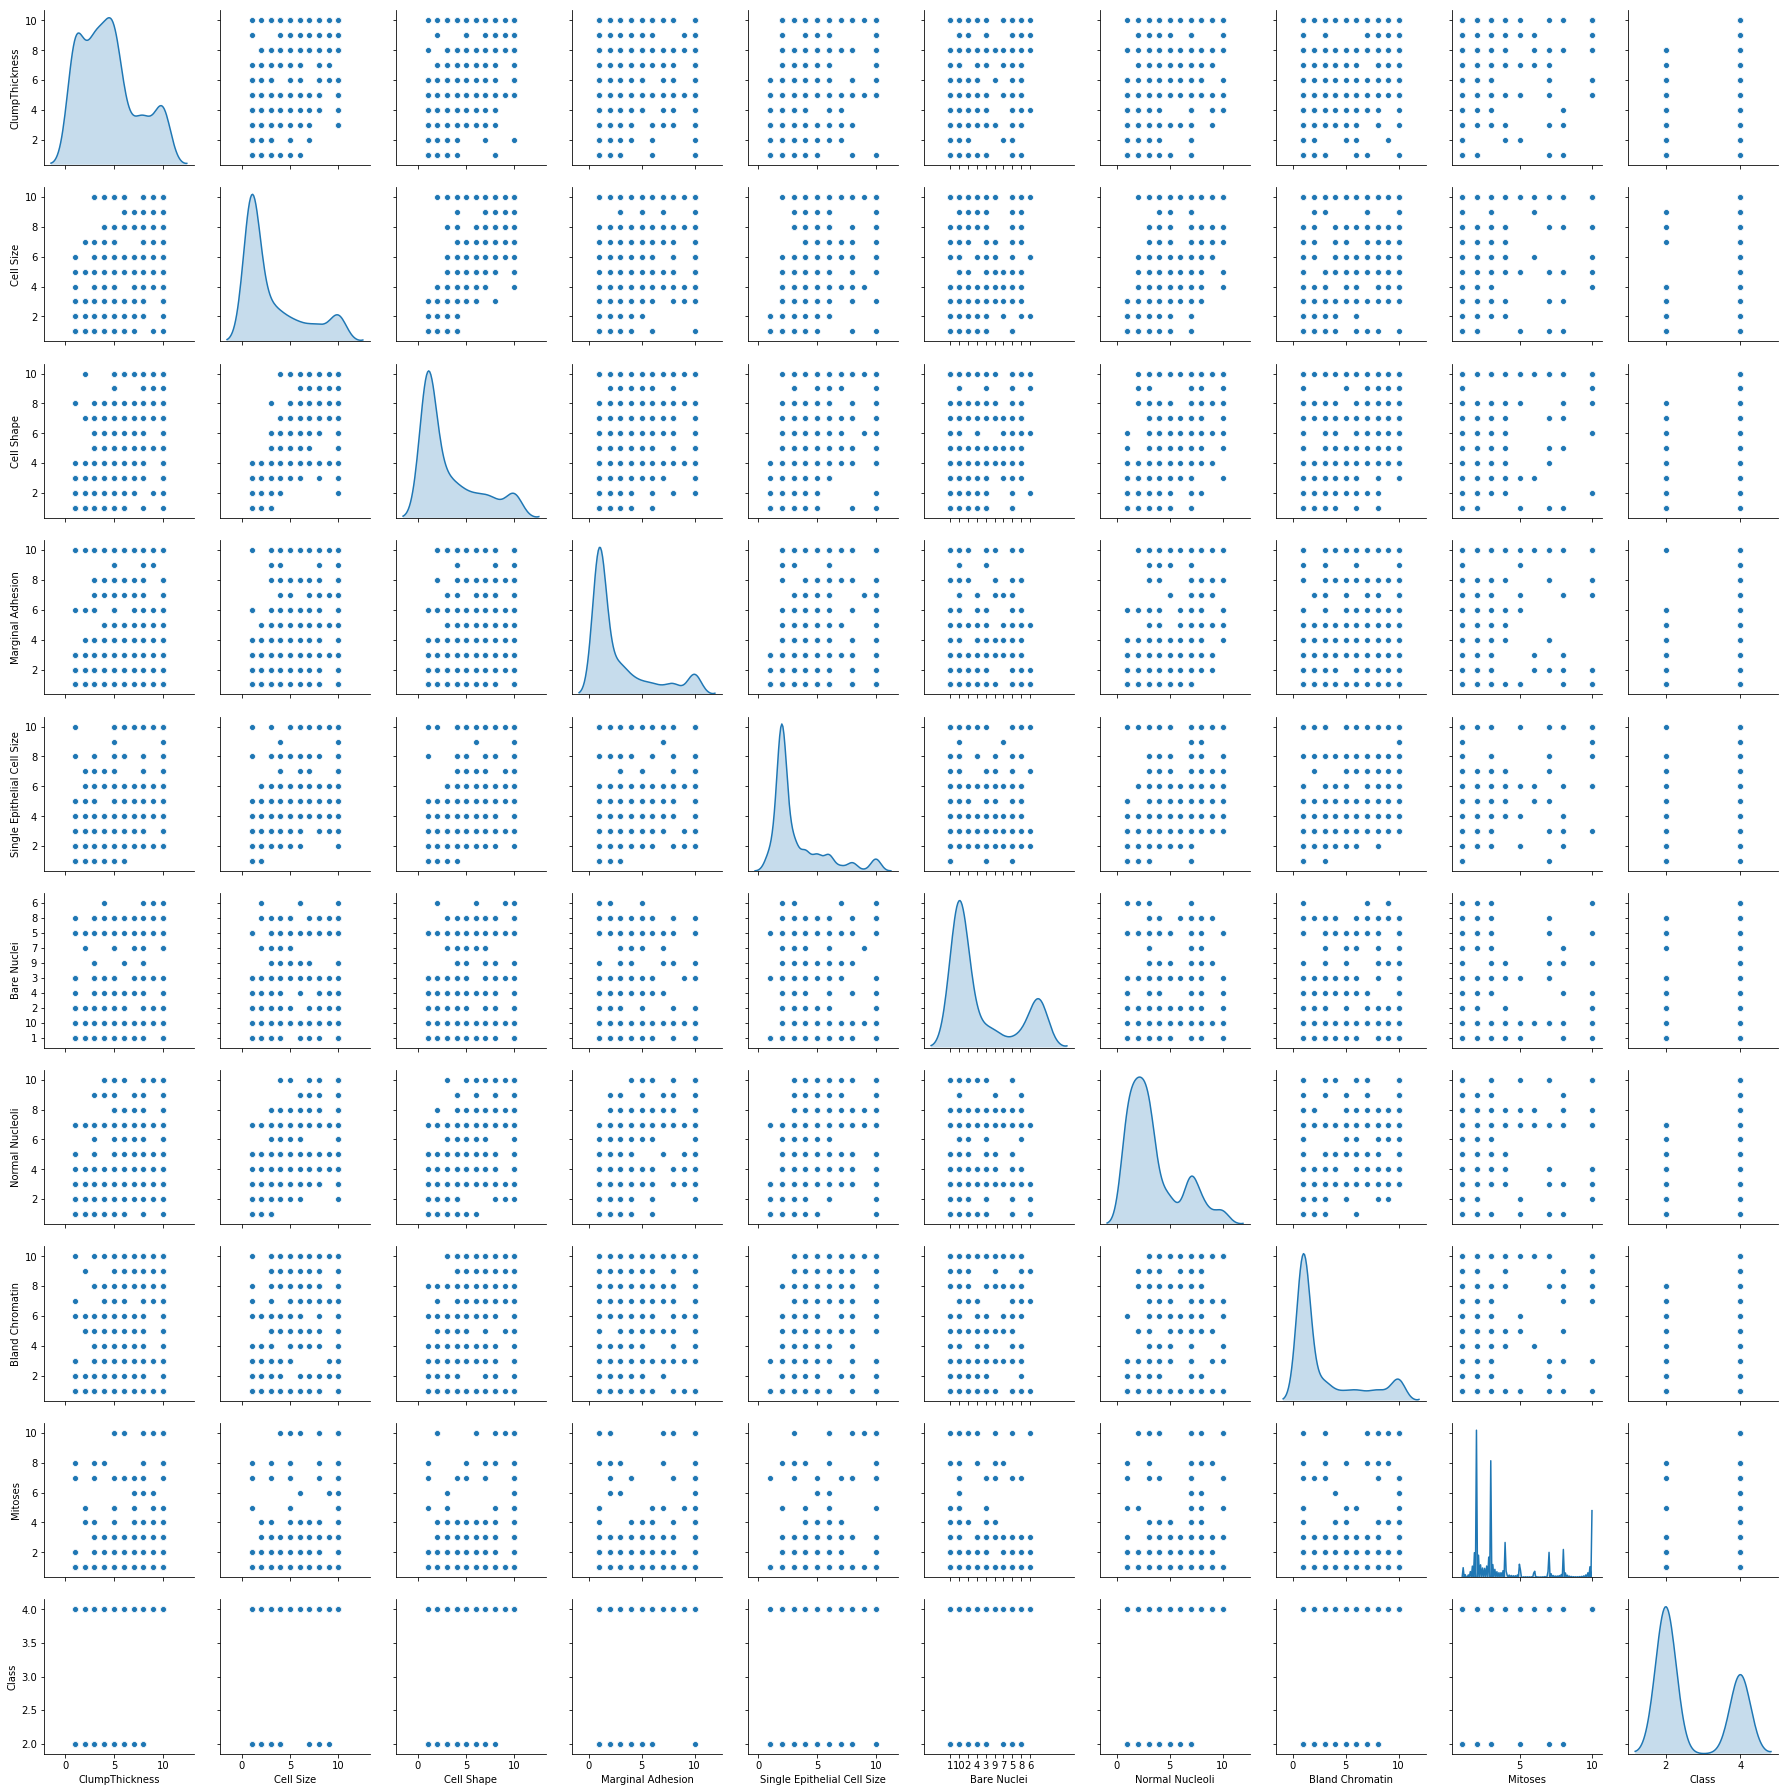

In [153]:
#Visually inspect the covariance between independent dimensions and between mpg and independent dimensions
sns.pairplot(cancer_df, diag_kind='kde') 

In [154]:
# Check for correlation of variable

In [155]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

Various clusters are found in the dataset.

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

In [156]:
# We could see most of the outliers are now removed.

In [157]:
X = cancer_df.drop("Class", axis=1)
y = cancer_df["Class"]

In [158]:
#Let us check for pair plots
X.shape

(683, 9)

# Q6 Create a covariance matrix for identifying Principal components

In [77]:
# PCA
# Step 1 - Create covariance matrix
# We transform (centralize) the entire X (independent variable data) to zscores through transformation. We will create the PCA dimensions
# on this distribution. 
sc = StandardScaler()
X_std =  sc.fit_transform(X)          
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[1.00146628 0.64342355 0.65442815 0.48854401 0.52436377 0.59396107
  0.55455439 0.534849   0.35147177]
 [0.64342355 1.00146628 0.90855848 0.70801357 0.75464892 0.69272299
  0.75666702 0.7204008  0.46143029]
 [0.65442815 0.90855848 1.00146628 0.68695385 0.72352174 0.71492429
  0.73642172 0.71901615 0.44190459]
 [0.48854401 0.70801357 0.68695385 1.00146628 0.59541954 0.67163165
  0.66954737 0.6040054  0.41951256]
 [0.52436377 0.75464892 0.72352174 0.59541954 1.00146628 0.58657495
  0.61903424 0.62984858 0.48128796]
 [0.59396107 0.69272299 0.71492429 0.67163165 0.58657495 1.00146628
  0.68161283 0.58513691 0.33970781]
 [0.55455439 0.75666702 0.73642172 0.66954737 0.61903424 0.68161283
  1.00146628 0.66657749 0.34651824]
 [0.534849   0.7204008  0.71901615 0.6040054  0.62984858 0.58513691
  0.66657749 1.00146628 0.43439328]
 [0.35147177 0.46143029 0.44190459 0.41951256 0.48128796 0.33970781
  0.34651824 0.43439328 1.00146628]]


C:\Users\Admin\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int64, object were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\Users\Admin\Anaconda3\lib\site-packages\sklearn\base.py:462: DataConversionWarning: Data with input dtype int64, object were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


# Q7 Identify eigen values and eigen vector

In [0]:
# Step 2- Get eigen values and eigen vector

In [78]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

Eigen Vectors 
%s [[-3.02062573e-01 -1.40800531e-01  8.66372452e-01  2.74743825e-03
   1.07828438e-01  8.03212439e-02 -2.47707288e-01  2.42517517e-01
  -8.51566756e-03]
 [-3.80792973e-01 -4.66403106e-02 -1.99378011e-02  7.33210938e-01
  -2.04255399e-01 -1.45652870e-01  4.36299814e-01  1.39031681e-01
  -2.05434260e-01]
 [-3.77582540e-01 -8.24224677e-02  3.35108706e-02 -6.67480798e-01
  -1.75865604e-01 -1.08391546e-01  5.82726744e-01  7.45271259e-02
  -1.27209198e-01]
 [-3.32723572e-01 -5.20943760e-02 -4.12647341e-01 -4.60192106e-02
   4.93172568e-01 -1.95689775e-02 -1.63434032e-01  6.54628771e-01
   1.23830400e-01]
 [-3.36234038e-01  1.64404385e-01 -8.77425288e-02 -6.68906225e-02
  -4.27383577e-01 -6.36693247e-01 -4.58669096e-01 -6.93089143e-02
   2.11018210e-01]
 [-3.35067511e-01 -2.61260621e-01  6.91477953e-04  7.65102933e-02
   4.98617672e-01 -1.24772942e-01  1.26652879e-01 -6.09220540e-01
   4.02790095e-01]
 [-3.45747366e-01 -2.28076759e-01 -2.13071845e-01 -6.22410470e-02
   1.30473

# Q8 Find variance and cumulative variance by each eigen vector

In [80]:
#Sort eigenvalues in descending order

# Make a set of (eigenvalue, eigenvector) pairs
eig_pairs = [(eigenvalues[index], eigenvectors[:,index]) for index in range(len(eigenvalues))]

# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()

eig_pairs.reverse()
print(eig_pairs)

# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(eigenvalues))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(eigenvalues))]

# Let's confirm our sorting worked, print out eigenvalues
print('Eigenvalues in descending order: \n%s' %eigvalues_sorted)

[(5.908149641714727, array([-0.30206257, -0.38079297, -0.37758254, -0.33272357, -0.33623404,
       -0.33506751, -0.34574737, -0.33559138, -0.2302064 ])), (0.7770846371660397, array([-0.14080053, -0.04664031, -0.08242247, -0.05209438,  0.16440439,
       -0.26126062, -0.22807676,  0.03396582,  0.90555729])), (0.5400429320713798, array([ 8.66372452e-01, -1.99378011e-02,  3.35108706e-02, -4.12647341e-01,
       -8.77425288e-02,  6.91477953e-04, -2.13071845e-01, -1.34248356e-01,
        8.04921698e-02])), (0.4603013949329083, array([ 0.10782844, -0.2042554 , -0.1758656 ,  0.49317257, -0.42738358,
        0.49861767,  0.01304734, -0.41711347,  0.25898781])), (0.3808334179016646, array([ 0.08032124, -0.14565287, -0.10839155, -0.01956898, -0.63669325,
       -0.12477294,  0.22766572,  0.69021015,  0.10504168])), (0.30231908501855825, array([ 0.24251752,  0.13903168,  0.07452713,  0.65462877, -0.06930891,
       -0.60922054, -0.29889733, -0.0215182 , -0.14834515])), (0.29483439023564695, arra

In [81]:
tot = sum(eigenvalues)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)]  # an array of variance explained by each 
# eigen vector... there will be 8 entries as there are 8 eigen vectors)
cum_var_exp = np.cumsum(var_explained)  # an array of cumulative variance. There will be 8 entries with 8 th entry 
# cumulative reaching almost 100%

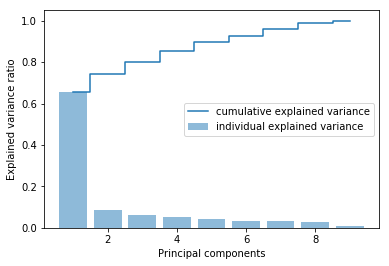

In [91]:
plt.bar(range(1,10), var_explained, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1,10),cum_var_exp, where= 'mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc = 'best')
plt.show()


# The plot shows that the first principal component alone accounts for 40 percent of the variance. 
# Also, we can see that the first two principal components combined explain almost 60 percent of the variance 
# in the data.

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [164]:
# Step 4: Project data onto lesser dimensions

P_reduce = np.array(eigvectors_sorted[0:6])   # Using all principal components
X_std_4D = np.dot(X_std,P_reduce.T)   # projecting original data into principal component dimensions
Proj_data_df = pd.DataFrame(X_std_4D)  # converting array to dataframe for pairplot


In [165]:
from sklearn import model_selection

test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = model_selection.train_test_split(Proj_data_df, y, test_size=test_size, random_state=seed)

# Q10 Find correlation between components and features

C:\Users\Admin\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:448: RuntimeWarning: invalid value encountered in greater
  X = X[np.logical_and(X > clip[0], X < clip[1])] # won't work for two columns.
C:\Users\Admin\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:448: RuntimeWarning: invalid value encountered in less
  X = X[np.logical_and(X > clip[0], X < clip[1])] # won't work for two columns.


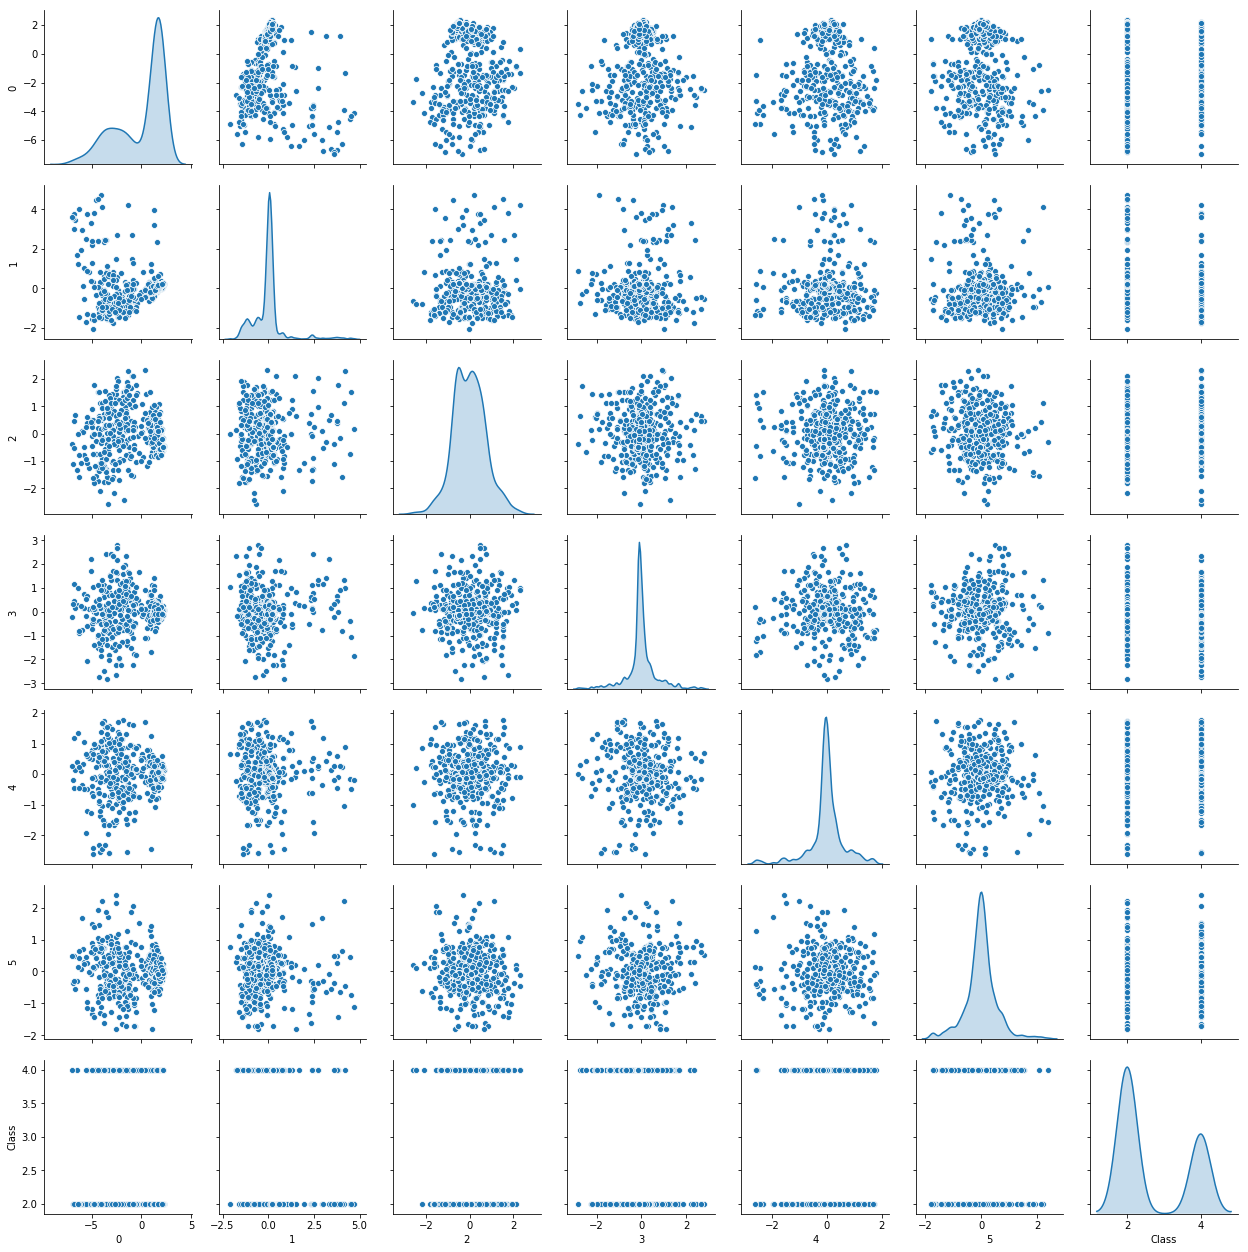

In [166]:
#Let us check it visually
Proj_data_mpg_df = Proj_data_df.join(y)

sns.pairplot(Proj_data_mpg_df, diag_kind='kde') 